In [43]:
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from hcc_multimodal.transforms import CLINICAL_X_COLUMNS, DataType, build_preprocessor

In [44]:
ROOT = Path().resolve().parents[1]


clinical_data = pd.read_csv(
    ROOT
    / "data"
    / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

radiomics_data = pd.read_csv(
    ROOT / "data" / "Radiomics" / "radiomic_cluster.csv"
).dropna(how="all")

In [45]:
# Extract death target before slicing to features-only
radiomic_death = radiomics_data[["SID", "death"]].copy()

radiomic_features = radiomics_data.iloc[:, :447]
radiomic_features.head()

,SID,FOS_Imode_art,FOS_RMS_art,FD_min_4gl_art,FD_max_8gl_art,FD_max_16gl_art,FOS_CV_LLL_art,GLSZM_ZoneHiGl_LLL_4gl_art,GLSZM_SzoneLoGl_LLL_4gl_art,FD_max_LLL_4gl_art,...,GrayLevelDistanceVariance3D_del,Strength3D_del,HighGrayLevelCountEmphasis3D_del,LowDependenceLowGrayLevelEmphasis3D_del,HighDependenceLowGrayLevelEmphasis3D_del,NormalisedGrayLevelDependenceNonUniformity3D_del,DependenceCountNonUniformity3D_del,DependenceCountPercentage3D_del,GrayLevelDependenceVariance3D_del,DependenceCountEnergy3D_del
0,10,0.054500,5.684342e-14,2.220446e-16,1.545338,1.382399,-0.087231,0.329302,-0.644365,1.413145,...,187.838745,0.279724,1041.486693,0.000845,0.199198,0.032734,20496.173622,1.0,89.412016,0.002408
1,113,0.940338,5.684342e-14,2.220446e-16,-0.557965,0.446411,-0.189954,-0.487316,-0.526493,0.427835,...,116.679761,0.566227,994.310655,0.000609,0.101982,0.029374,8924.565394,1.0,94.850739,0.002905
2,114,0.116041,-4.263256e-14,2.220446e-16,-0.557965,-0.428548,-0.169633,0.376952,-0.338859,0.427835,...,148.178396,0.773768,1066.921956,0.002644,0.040481,0.042071,4619.093598,1.0,72.498770,0.005332
3,115,-0.236033,5.684342e-14,2.220446e-16,-0.557965,-0.428548,0.405745,1.766959,-0.748305,-0.966984,...,113.861229,1.225344,996.187582,0.000673,0.063853,0.029875,4941.431914,1.0,92.728957,0.004365
4,121,0.086705,5.684342e-14,2.220446e-16,-0.557965,0.446411,-0.064044,0.985651,-0.701062,1.413145,...,145.589322,2.145185,1028.721837,0.000873,0.041845,0.028969,2683.416328,1.0,97.945953,0.003874


In [46]:
sid_clinical = set(clinical_data["SID"].values)
sid_radiomics = set(radiomic_features["SID"].values)

overlapping_sids = sid_clinical.intersection(sid_radiomics)
print(f"Number of overlapping SIDs: {len(overlapping_sids)}")

Number of overlapping SIDs: 60


In [47]:
# Join on SID, keeping only patients present in both datasets
merged = clinical_data.merge(
    radiomic_features, on="SID", how="inner", suffixes=("_clin", "_rad")
)
print(f"Merged shape: {merged.shape}")

Merged shape: (60, 635)


In [48]:
# Radiomic features (all numeric columns except SID)
radiomic_cols = [c for c in radiomic_features.columns if c != "SID"]
radiomic_x_columns = {col: DataType.CONTINUOUS for col in radiomic_cols}

# Combined column spec (clinical + radiomic)
combined_x_columns = {**CLINICAL_X_COLUMNS, **radiomic_x_columns}
print(
    f"Total features: {len(combined_x_columns)}  "
    f"(clinical: {len(CLINICAL_X_COLUMNS)}, radiomic: {len(radiomic_x_columns)})"
)

Total features: 457  (clinical: 11, radiomic: 446)


In [57]:
def run_cv_experiment(X, y, x_columns, label, n_splits=3):
    """Run 3-fold CV for LR and RF with PCA preprocessing. Returns (summary_df, fold_df)."""
    models = {
        "LR": LogisticRegression(
            l1_ratio=1.0, solver="liblinear", max_iter=1000, random_state=42
        ),
        "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    }
    preprocessor = build_preprocessor(x_columns)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    mask = ~y.isna()
    X_clean, y_clean = X[mask], y[mask]
    print(
        f"[{label}]  n={len(y_clean)}  positives={int(y_clean.sum())}  features={X_clean.shape[1]}"
    )

    records, fold_records = [], []
    for model_name, model in models.items():
        pipe = Pipeline(
            [
                ("preprocessor", preprocessor),
                ("pca", PCA(n_components=0.9, random_state=42)),
                ("model", model),
            ]
        )
        scores = cross_validate(
            pipe,
            X_clean,
            y_clean,
            cv=cv,
            scoring=["roc_auc", "accuracy"],
            return_train_score=True,
        )
        records.append(
            {
                "experiment": label,
                "model": model_name,
                "AUC mean": round(scores["test_roc_auc"].mean(), 3),
                "AUC std": round(scores["test_roc_auc"].std(), 3),
                "Accuracy mean": round(scores["test_accuracy"].mean(), 3),
                "Accuracy std": round(scores["test_accuracy"].std(), 3),
            }
        )
        for fold_i, (train_auc, test_auc) in enumerate(
            zip(scores["train_roc_auc"], scores["test_roc_auc"])
        ):
            fold_records.append(
                {
                    "experiment": label,
                    "model": model_name,
                    "fold": fold_i + 1,
                    "train_auc": train_auc,
                    "test_auc": test_auc,
                }
            )
    return pd.DataFrame(records), pd.DataFrame(fold_records)


def plot_pca_variance(X_pre, title="PCA on preprocessed features"):
    n_components = min(X_pre.shape)
    pca_full = PCA(n_components=n_components).fit(X_pre)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    threshold = 0.90
    n_90 = int(np.searchsorted(cumvar, threshold)) + 1

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    ax = axes[0]
    ax.plot(np.arange(1, len(cumvar) + 1), cumvar, color="steelblue", linewidth=1.5)
    ax.axhline(threshold, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(
        n_90,
        color="tomato",
        linestyle="--",
        linewidth=0.8,
        label=f"{n_90} components → {threshold:.0%} variance",
    )
    ax.set_xlabel("Number of PCA components")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_title("Cumulative variance explained")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.bar(np.arange(1, 31), pca_full.explained_variance_ratio_[:30], color="steelblue")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Explained variance ratio")
    ax.set_title("Per-component variance (first 30)")
    ax.grid(axis="y", alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f"Components to reach {threshold:.0%} variance: {n_90} / {X_pre.shape[1]}")


def plot_cv_results(fold_df, title="Cross-validation AUC"):
    model_names = fold_df["model"].unique().tolist()
    colors = ["steelblue", "seagreen"]
    y_pos = np.arange(len(model_names))

    fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
    for col, split in enumerate(["train", "test"]):
        ax = axes[col]
        for y_idx, (model_name, color) in enumerate(zip(model_names, colors)):
            df = fold_df[fold_df["model"] == model_name]
            aucs = df[f"{split}_auc"].values
            ax.scatter(aucs, [y_idx] * len(aucs), color=color, s=60, zorder=3)
            ax.scatter(aucs.mean(), y_idx, marker="D", color=color, s=90, zorder=4)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(model_names)
        ax.set_xlabel("AUC")
        ax.set_title(f"{'Train' if split == 'train' else 'Test'} AUC")
        ax.grid(axis="x", alpha=0.3)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

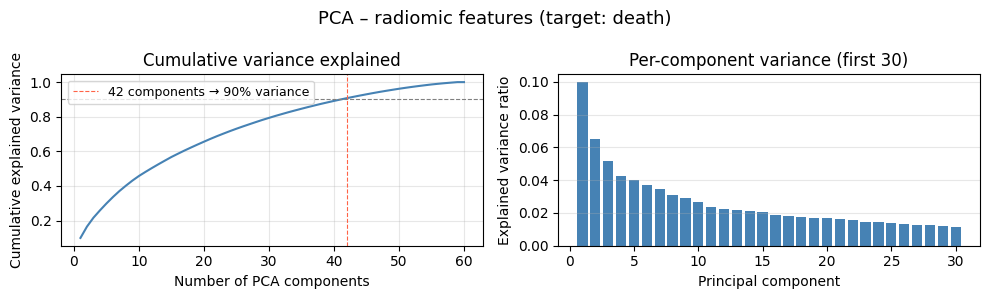

Components to reach 90% variance: 42 / 446
[Radiomic → death]  n=60  positives=24  features=446


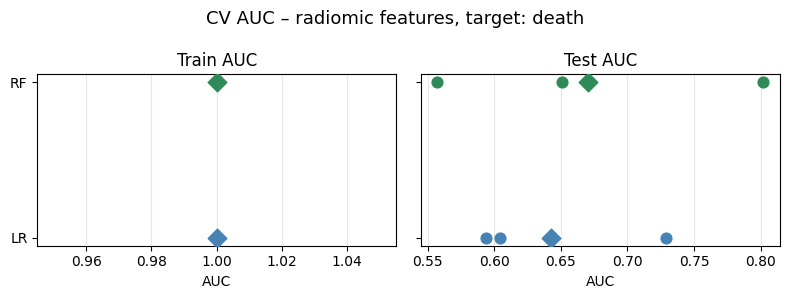

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic → death,LR,0.642,0.062,0.583,0.062
1,Radiomic → death,RF,0.670,0.101,0.667,0.024


In [58]:
# === Experiment 1: Radiomic features only, target = death (from radiomics CSV) ===
X_exp1 = radiomic_features.set_index("SID")[radiomic_cols]
y_exp1 = radiomic_death.set_index("SID")["death"]
# Align (same source, but be explicit)
common = X_exp1.index.intersection(y_exp1.index)
X_exp1 = X_exp1.loc[common].reset_index(drop=True)
y_exp1 = y_exp1.loc[common].reset_index(drop=True)

X_pre1 = build_preprocessor(radiomic_x_columns).fit_transform(X_exp1[~y_exp1.isna()])
plot_pca_variance(X_pre1, title="PCA – radiomic features (target: death)")

cv_results1, fold_df1 = run_cv_experiment(
    X_exp1, y_exp1, radiomic_x_columns, label="Radiomic → death"
)
plot_cv_results(fold_df1, title="CV AUC – radiomic features, target: death")
cv_results1

Experiment 2 dataset size: 60


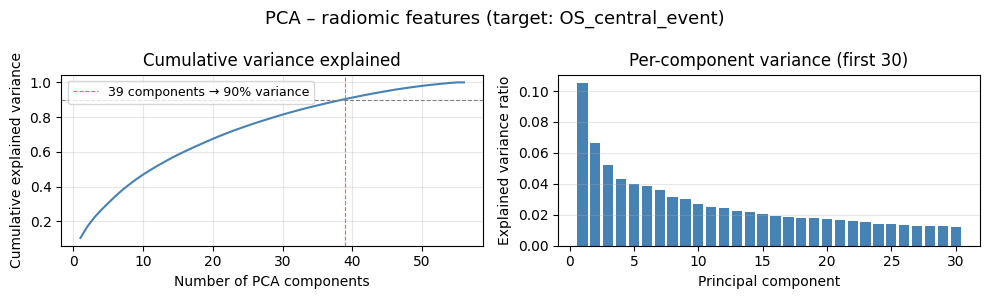

Components to reach 90% variance: 39 / 446
[Radiomic → OS_central_event]  n=56  positives=21  features=446


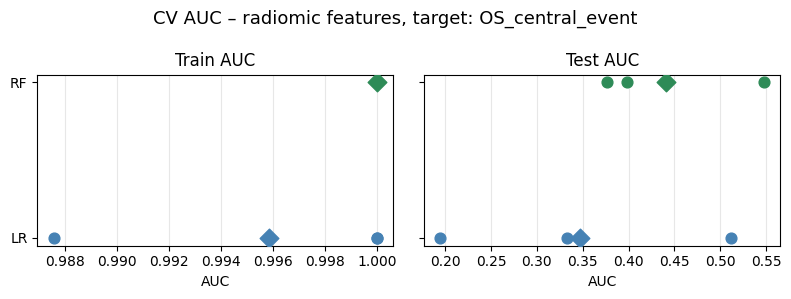

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic → OS_central_event,LR,0.347,0.130,0.443,0.125
1,Radiomic → OS_central_event,RF,0.441,0.076,0.517,0.055


In [59]:
# === Experiment 2: Radiomic features only, target = OS_central_event (from clinical) ===
rad_with_clin_y = radiomic_features.merge(
    clinical_data[["SID", "OS_central_event"]], on="SID", how="inner"
)
print(f"Experiment 2 dataset size: {len(rad_with_clin_y)}")

X_exp2 = rad_with_clin_y[radiomic_cols].reset_index(drop=True)
y_exp2 = rad_with_clin_y["OS_central_event"].reset_index(drop=True)

X_pre2 = build_preprocessor(radiomic_x_columns).fit_transform(X_exp2[~y_exp2.isna()])
plot_pca_variance(X_pre2, title="PCA – radiomic features (target: OS_central_event)")

cv_results2, fold_df2 = run_cv_experiment(
    X_exp2, y_exp2, radiomic_x_columns, label="Radiomic → OS_central_event"
)
plot_cv_results(fold_df2, title="CV AUC – radiomic features, target: OS_central_event")
cv_results2

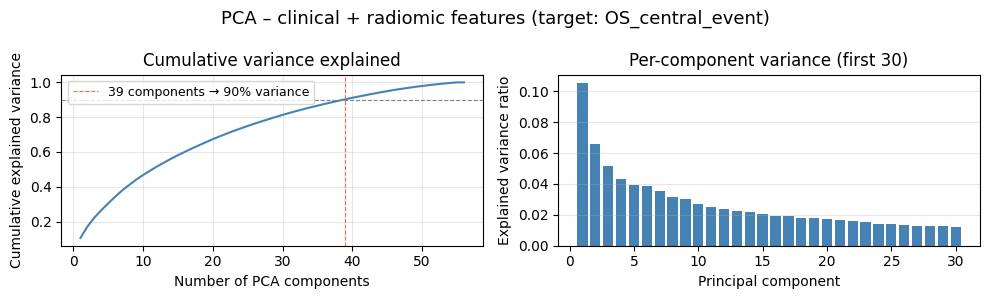

Components to reach 90% variance: 39 / 472
[Clinical+Radiomic → OS_central_event]  n=56  positives=21  features=457


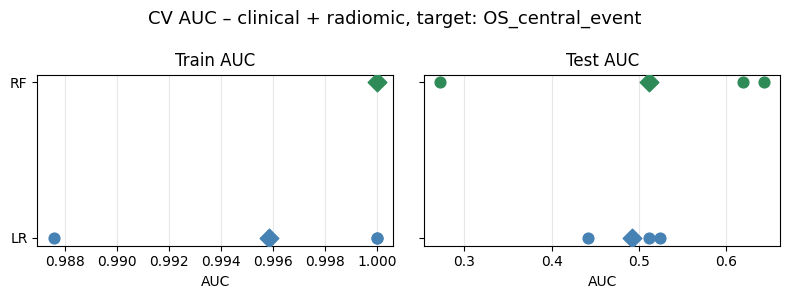

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Clinical+Radiomic → OS_central_event,LR,0.492,0.036,0.463,0.057
1,Clinical+Radiomic → OS_central_event,RF,0.512,0.169,0.588,0.075


In [60]:
# === Experiment 3: Clinical + Radiomic features, target = OS_central_event ===
X_exp3 = merged[list(combined_x_columns.keys())]
y_exp3 = merged["OS_central_event"]

X_pre3 = build_preprocessor(combined_x_columns).fit_transform(X_exp3[~y_exp3.isna()])
plot_pca_variance(
    X_pre3, title="PCA – clinical + radiomic features (target: OS_central_event)"
)

cv_results3, fold_df3 = run_cv_experiment(
    X_exp3, y_exp3, combined_x_columns, label="Clinical+Radiomic → OS_central_event"
)
plot_cv_results(
    fold_df3, title="CV AUC – clinical + radiomic, target: OS_central_event"
)
cv_results3

                          experiment model  AUC mean  AUC std  Accuracy mean  Accuracy std
                    Radiomic → death    LR     0.642    0.062          0.583         0.062
                    Radiomic → death    RF     0.670    0.101          0.667         0.024
         Radiomic → OS_central_event    LR     0.347    0.130          0.443         0.125
         Radiomic → OS_central_event    RF     0.441    0.076          0.517         0.055
Clinical+Radiomic → OS_central_event    LR     0.492    0.036          0.463         0.057
Clinical+Radiomic → OS_central_event    RF     0.512    0.169          0.588         0.075


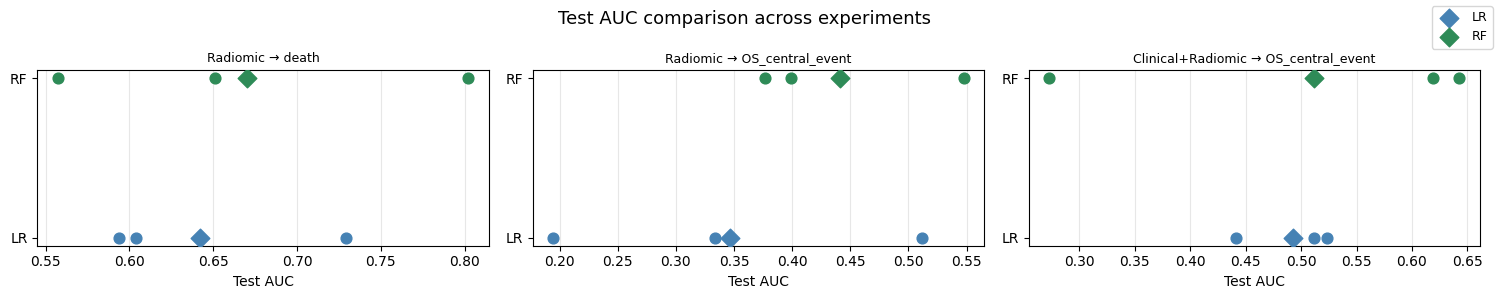

In [61]:
# === Combined comparison across all three experiments ===
all_cv = pd.concat([cv_results1, cv_results2, cv_results3], ignore_index=True)
all_folds = pd.concat([fold_df1, fold_df2, fold_df3], ignore_index=True)

print(all_cv.to_string(index=False))

experiments = all_folds["experiment"].unique().tolist()
model_names = all_folds["model"].unique().tolist()
colors = ["steelblue", "seagreen"]

fig, axes = plt.subplots(
    1, len(experiments), figsize=(5 * len(experiments), 3), sharey=False
)
for ax, exp_name in zip(axes, experiments):
    df_exp = all_folds[all_folds["experiment"] == exp_name]
    y_pos = np.arange(len(model_names))
    for y_idx, (model_name, color) in enumerate(zip(model_names, colors)):
        aucs = df_exp[df_exp["model"] == model_name]["test_auc"].values
        ax.scatter(aucs, [y_idx] * len(aucs), color=color, s=60, zorder=3)
        ax.scatter(
            aucs.mean(),
            y_idx,
            marker="D",
            color=color,
            s=90,
            zorder=4,
            label=model_name,
        )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_names)
    ax.set_xlabel("Test AUC")
    ax.set_title(exp_name, fontsize=9)
    ax.grid(axis="x", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9)
fig.suptitle("Test AUC comparison across experiments", fontsize=13)
plt.tight_layout()
plt.show()